# Predikcija otkazivanja hotelskih rezervacija primenom neuronskih mreža i algoritama mašinskog učenja

# Biblioteke

In [89]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# EDA

Cilj ovog dela je uočavanje obrazaca, razumevanje podataka i pronalaženje mogućih anomalija u podacima.

In [37]:
df = pd.read_csv("data/hotel_booking.csv")
print(f"Broj redova: {df.shape[0]}, broj kolona: {df.shape[1]}")

Broj redova: 119390, broj kolona: 36


In [38]:
print(f"Kolone: {df.columns.to_list()}")

Kolone: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


In [72]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


Kolone name, email, phone-number i credit_card predstavljaju sintetičke ili privatne identifikatore korisnika koji nemaju prediktivnu moć i biće uklonjeni.

Curenje podataka: Kolone reservation_status (Check-Out, Canceled, No-Show) i reservation_status_date direktno otkrivaju ishod boravka. U realnom scenariju predikcije ove informacije nisu poznate u trenutku rezervacije, te se moraju ukloniti pre obučavanja modela.

In [40]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


**Uočena anomalija**

Kolona "adr" (prosečna dnevna cena): Minimalna vrednost je -6.38 (negativna cena noćenja je logička greška u podacima). Maksimalna vrednost: 5400.00 (ekstremni autlajer u odnosu na medijanu od 94.58).

In [ ]:
df.loc[df['adr'] < 0].shape[0]

1

In [42]:
df['adr'].nlargest(5)

48515     5400.0
111403     510.0
15083      508.0
103912     451.5
13142      450.0
Name: adr, dtype: float64

In [43]:
df.loc[df['adr'] > 510].shape[0]

1

Ekstremne minimalne i maksimalne vrednosti za 'adr' su retke(po jedan primerak). Bezbedno ih je onda ukloniti kako ne bi narušili skaliranje za modele

In [44]:
(df.loc[(df['adults']==0) & (df['babies']==0) & (df['children']==0)]).shape[0]

180

In [45]:
df.loc[df['adults']< 1].shape[0]

403

**Logička nekonzistentnost**

Pristutne su rezervacije gde je ukupan broj odraslih, dece i beba jednak 0 što predstavlja nevalidne unose.

Primećujemo i da je mnogo veći broj redova gde je broj odraslih jednak nuli. Deca ili bebe ne mogu sami rezervisati niti boraviti u hotelu bez odrasle osobe.

Ove redove najbolje ukloniti, kako modeli ne bi učili iz šuma, 403 od 119390 redova je zanemarljiv gubitak.

In [46]:
df.loc[df['babies'] > 2, ['babies', 'children', 'adults', 'customer_type']]

,babies,children,adults,customer_type
46619,10,0.0,2,Transient
78656,9,0.0,1,Transient-Party


In [47]:
df.loc[df['children'] > 3, ['babies', 'children', 'adults', 'customer_type']]

,babies,children,adults,customer_type
328,0,10.0,2,Contract


**Logička nemogućnost**

Dvoje odraslih da čuva 9-10 dece ili beba van grupne organizacije je nerealistično. Ovi podaci će biti uklonjeni.

In [48]:
df.describe(include = 'object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,669-792-1661,************3627
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,48,6,1,28


reserved_room_type i assigned_room_type imaju drugačiji broj unikatnih vrednosti, hotel verovatno ima sobe koje ne prikazuje javnosti pri rezervaciji

In [49]:
print(df.dtypes)

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [50]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
print("Kolone sa nedostajucim vrednostima")
missing_df = pd.DataFrame({"Broj nedostajucih vrednosti": missing, "Procenat": missing_percent})
display(missing_df)

Kolone sa nedostajucim vrednostima


,Broj nedostajucih vrednosti,Procenat
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


Obeležje "company" ima ogroman procenat nedostajućih vrednosti što ukazuje na to da većina rezervacija nije napravljena preko kompanija. Kolona u izvornom obliku nije upotrebljiva i zahteva uklanjanje.

Nedostajuće vrednosti za kolonu "agent" ukazuje na direktne rezervacije(bez posredovanja agencije). Nedostajuće vrednosti mogu biti zamenjene sa 0.

Kolone "country" i "children" imaju zanemarljiv procenat nedostajućih vrednosti. Država se može zameniti posebnom kategorijom "Unknown", vrednost za decu 0 (većinski prisutna vrednost za tu kolonu).

In [51]:
print(f"Broj duplikata {df.duplicated().sum()}")

Broj duplikata 0


In [52]:
numerical_cols = df.select_dtypes(include= 'number').columns.to_list()
categorical_cols = df.select_dtypes(include='object').columns.to_list()
print(f"Numericke kolone: {numerical_cols}")
print(f"Kategoricke kolone: {categorical_cols}")

Numericke kolone: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Kategoricke kolone: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


In [73]:
cat_summary = pd.DataFrame([
    {
        'Kolona': c,
        'Broj unikatnih': df[c].nunique(),
        'Unikatne vrednosti': list(df[c].unique())
    }
    for c in categorical_cols
])

display(cat_summary)

,Kolona,Broj unikatnih,Unikatne vrednosti
0,hotel,2,"[Resort Hotel, City Hotel]"
1,arrival_date_month,12,"[July, August, September, October, November, D..."
2,meal,5,"[BB, FB, HB, SC, Undefined]"
3,country,177,"[PRT, GBR, USA, ESP, IRL, FRA, nan, ROU, NOR, ..."
4,market_segment,8,"[Direct, Corporate, Online TA, Offline TA/TO, ..."
5,distribution_channel,5,"[Direct, Corporate, TA/TO, Undefined, GDS]"
6,reserved_room_type,10,"[C, A, D, E, G, F, H, L, P, B]"
7,assigned_room_type,12,"[C, A, D, E, G, F, I, B, H, P, L, K]"
8,deposit_type,3,"[No Deposit, Refundable, Non Refund]"
9,customer_type,4,"[Transient, Contract, Transient-Party, Group]"


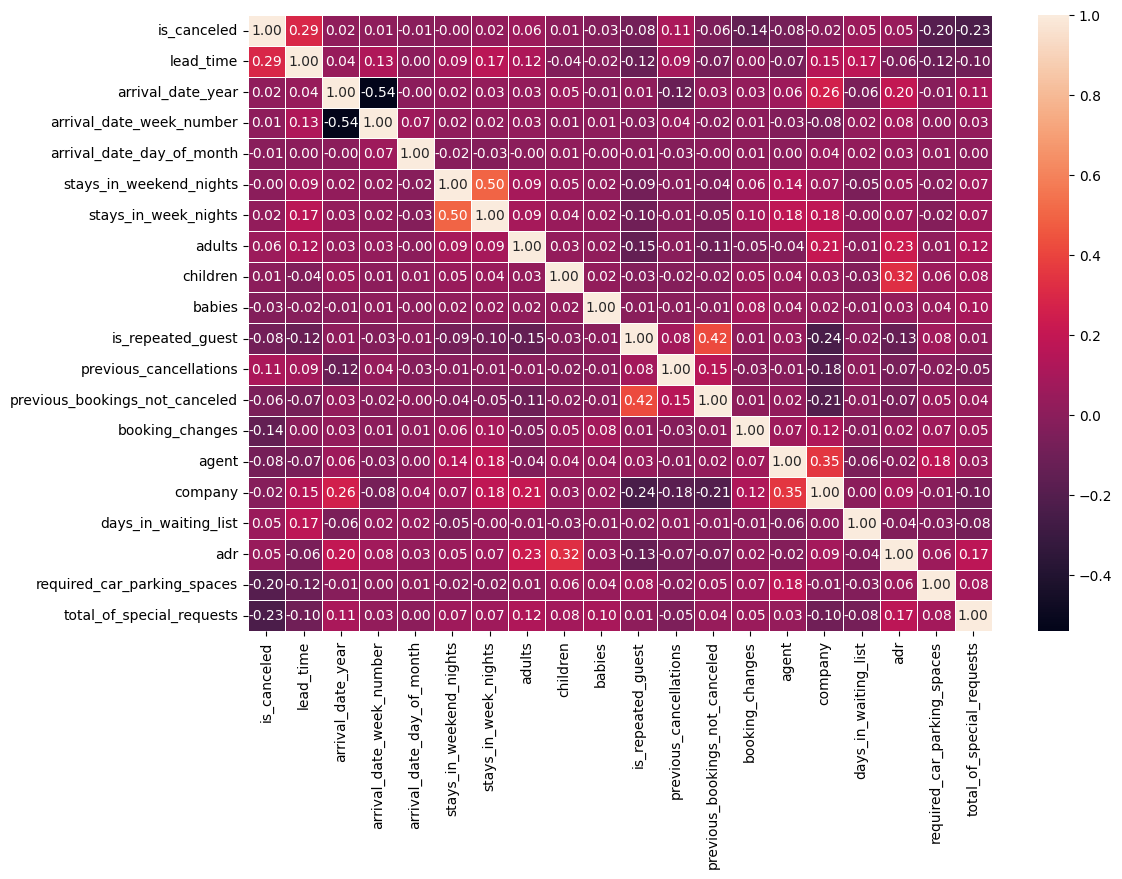

In [55]:
corr_mat = df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sb.heatmap(
    corr_mat,
    annot = True,
    fmt = '.2f',
    linewidths= 0.4
)
plt.show()

Korelaciona matrica  pokazuje uglavnom slabu međusobnu linearnu zavisnost, što odgovara modelima jer izbegava multikolinearnost. 

Uočene su dve umerene korelacije:
    
1. arrival_date_year i arrival_date_week_number: Očekivana korelacija usled načina na koji su podaci prikupljani kroz godine i kalendarske nedelje.

2. previous_bookings_not_canceled i is_repeated_guest: Logična pozitivna korelacija, povratni gosti po pravilu imaju prethodno realizovane rezervacije.

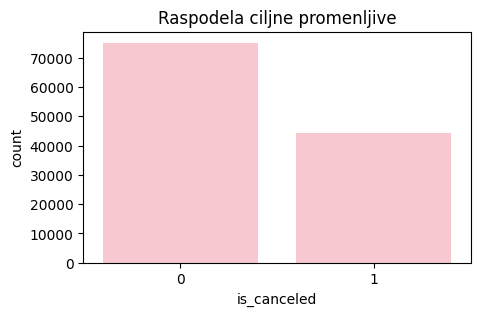

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

In [67]:
plt.figure(figsize=(5,3))
sb.countplot(x='is_canceled', data=df, color='pink')
plt.title('Raspodela ciljne promenljive')
plt.show()
df['is_canceled'].value_counts(normalize=True) * 100

Prisutan je blagi disbalans klasa. Disbalans nije kritičan, ali diktira primenu metrika kao što su F1-score, Precision, Recall umesto samo tačnosti (Accuracy).

In [58]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [59]:
df['agent'].value_counts()

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
444.0        1
408.0        1
388.0        1
453.0        1
480.0        1
Name: count, Length: 333, dtype: int64

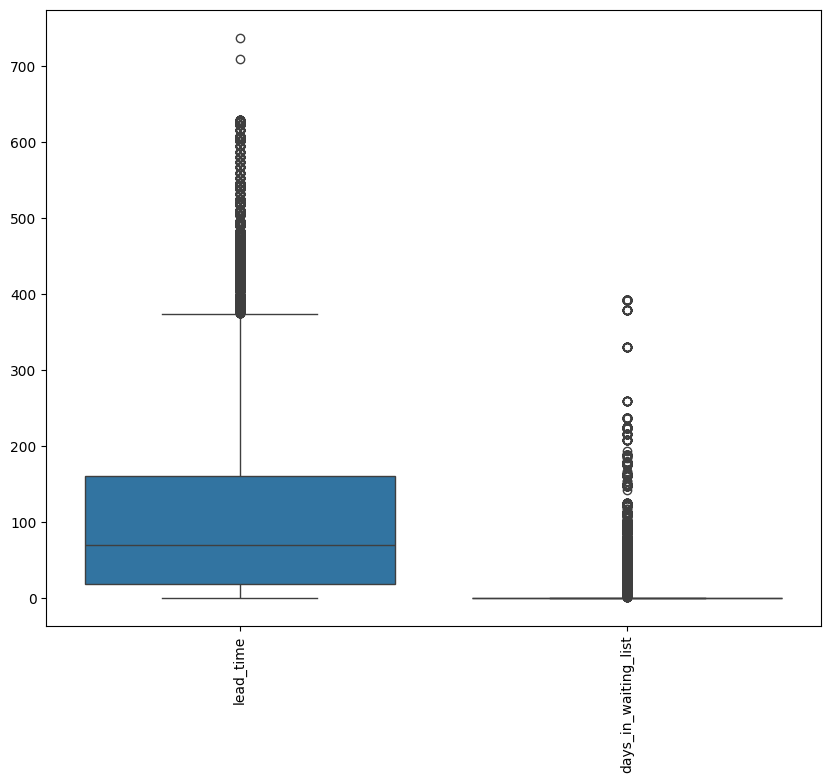

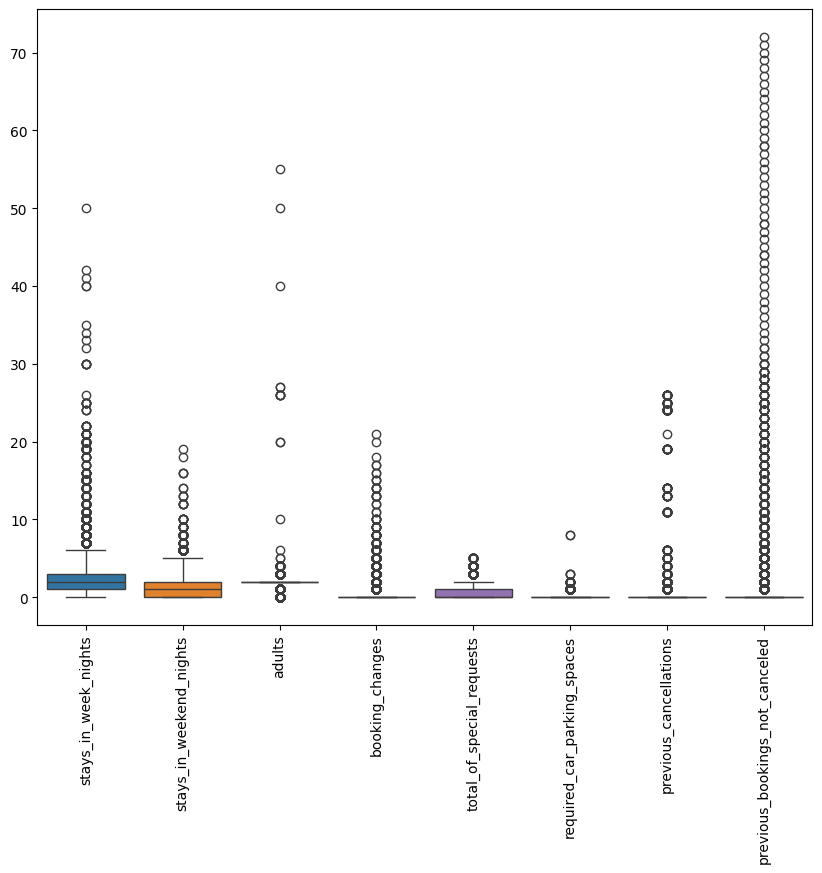

In [68]:
groups = {
    "longer": ['lead_time', 'days_in_waiting_list'],
    "shorter": ['stays_in_week_nights', 'stays_in_weekend_nights', 'adults', 'booking_changes',
                'total_of_special_requests', 'required_car_parking_spaces', 
        'previous_cancellations', 'previous_bookings_not_canceled']
    
}

for group_name, cols in groups.items():
    plt.figure(figsize=(10,8))
    sb.boxplot(data=df[groups[group_name]])
    plt.xticks(rotation=90)
    plt.show()

In [61]:
print("Raspodela 'customer_type' za veliki broj odraslih")
print(df[df['adults'] > 4]['customer_type'].value_counts())


Raspodela 'customer_type' za veliki broj odraslih
customer_type
Group    16
Name: count, dtype: int64


Autlajeri za broj odraslih samo označava grupne rezervacije.

Autlajera za broj noćenja ima dosta ali to jesu realne brojke, neki gosti bukiraju duže boravke od par meseci. 

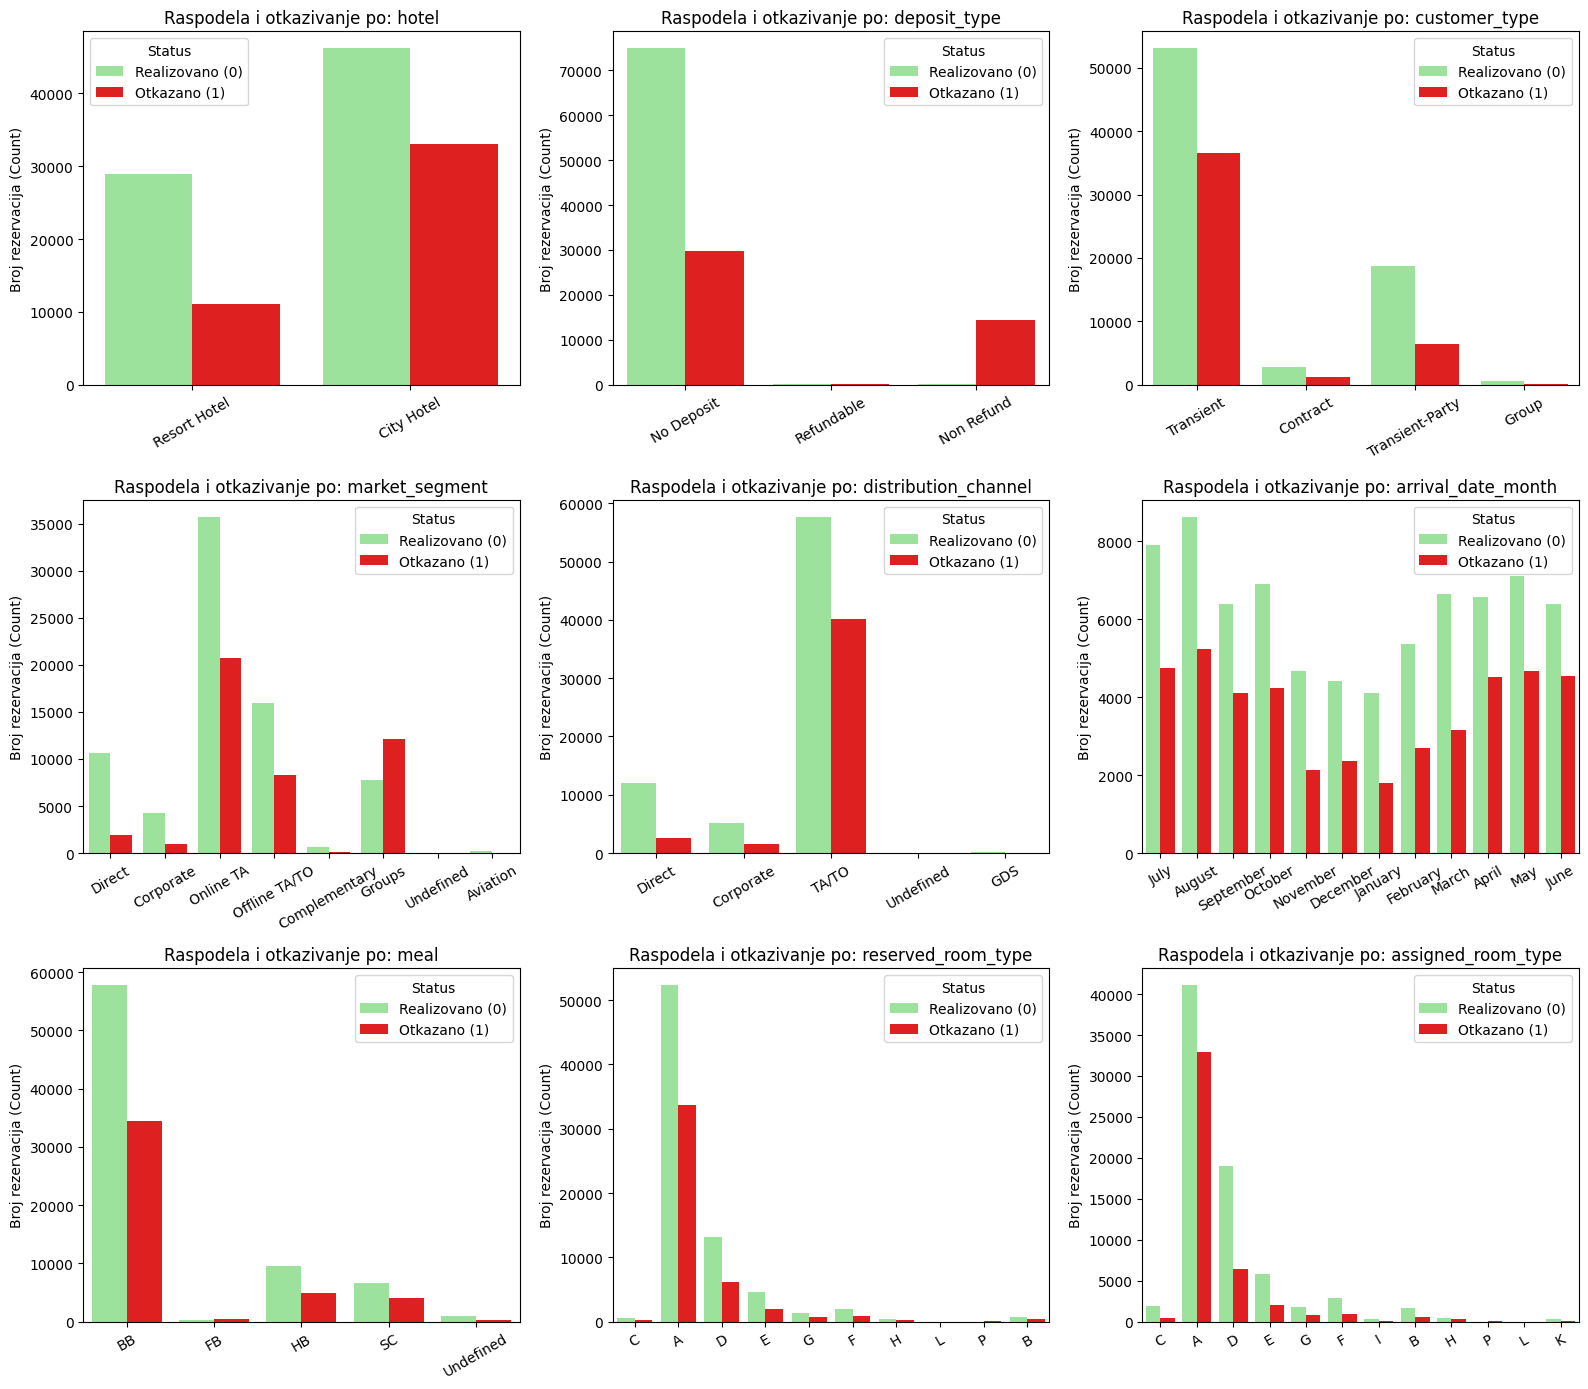

In [70]:
cols_to_plot = [
    'hotel', 'deposit_type', 'customer_type', 
    'market_segment', 'distribution_channel', 'arrival_date_month', 'meal', 'reserved_room_type', 'assigned_room_type'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    sb.countplot( data=df, x=col, hue='is_canceled', ax=ax, palette={0: 'lightgreen', 1: 'r'})
    
    ax.set_title(f'Raspodela i otkazivanje po: {col}')
    ax.set_ylabel('Broj rezervacija (Count)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['Realizovano (0)', 'Otkazano (1)'], title='Status')
    

plt.tight_layout()
plt.show()

**Zapažanja**

Interesantno zapažanje je da kod rezervacija bez povrata novca dominira status "otkazano" dok je kod rezervacija bez ikakvog depozita obrnuta situacija.

Avgust je najdominantniji mesec za rezervaciju, dok su rezervacije slabije tokom zime.

Gradski hoteli imaju višu stopu otkazivanja od odmarališta. Iz druge perspektive: Gradski hoteli imaju veći broj rezervacija od rizorta, pa se može zaključiti da što je više  rezervacija, to je viša stopa otkazivanja.

Kod sobe "D" je češće dat kupcima nego što je rezervisan i obrnuto za sobu "A". Uočava se i promena statusa rezervacije zbog toga. Što ukazuje da gosti zbog upgrade-a/downgrade-a promene mišljenje.

Stopa otkazivanja je veća za Full Board plan ishrane

Rezervacije se najčešće vrše preko Online agencija. Kod grupnih rezervacija ima značajno više otkazivanja. Dok su "najuspešnije" direktne hotelske rezervacije.

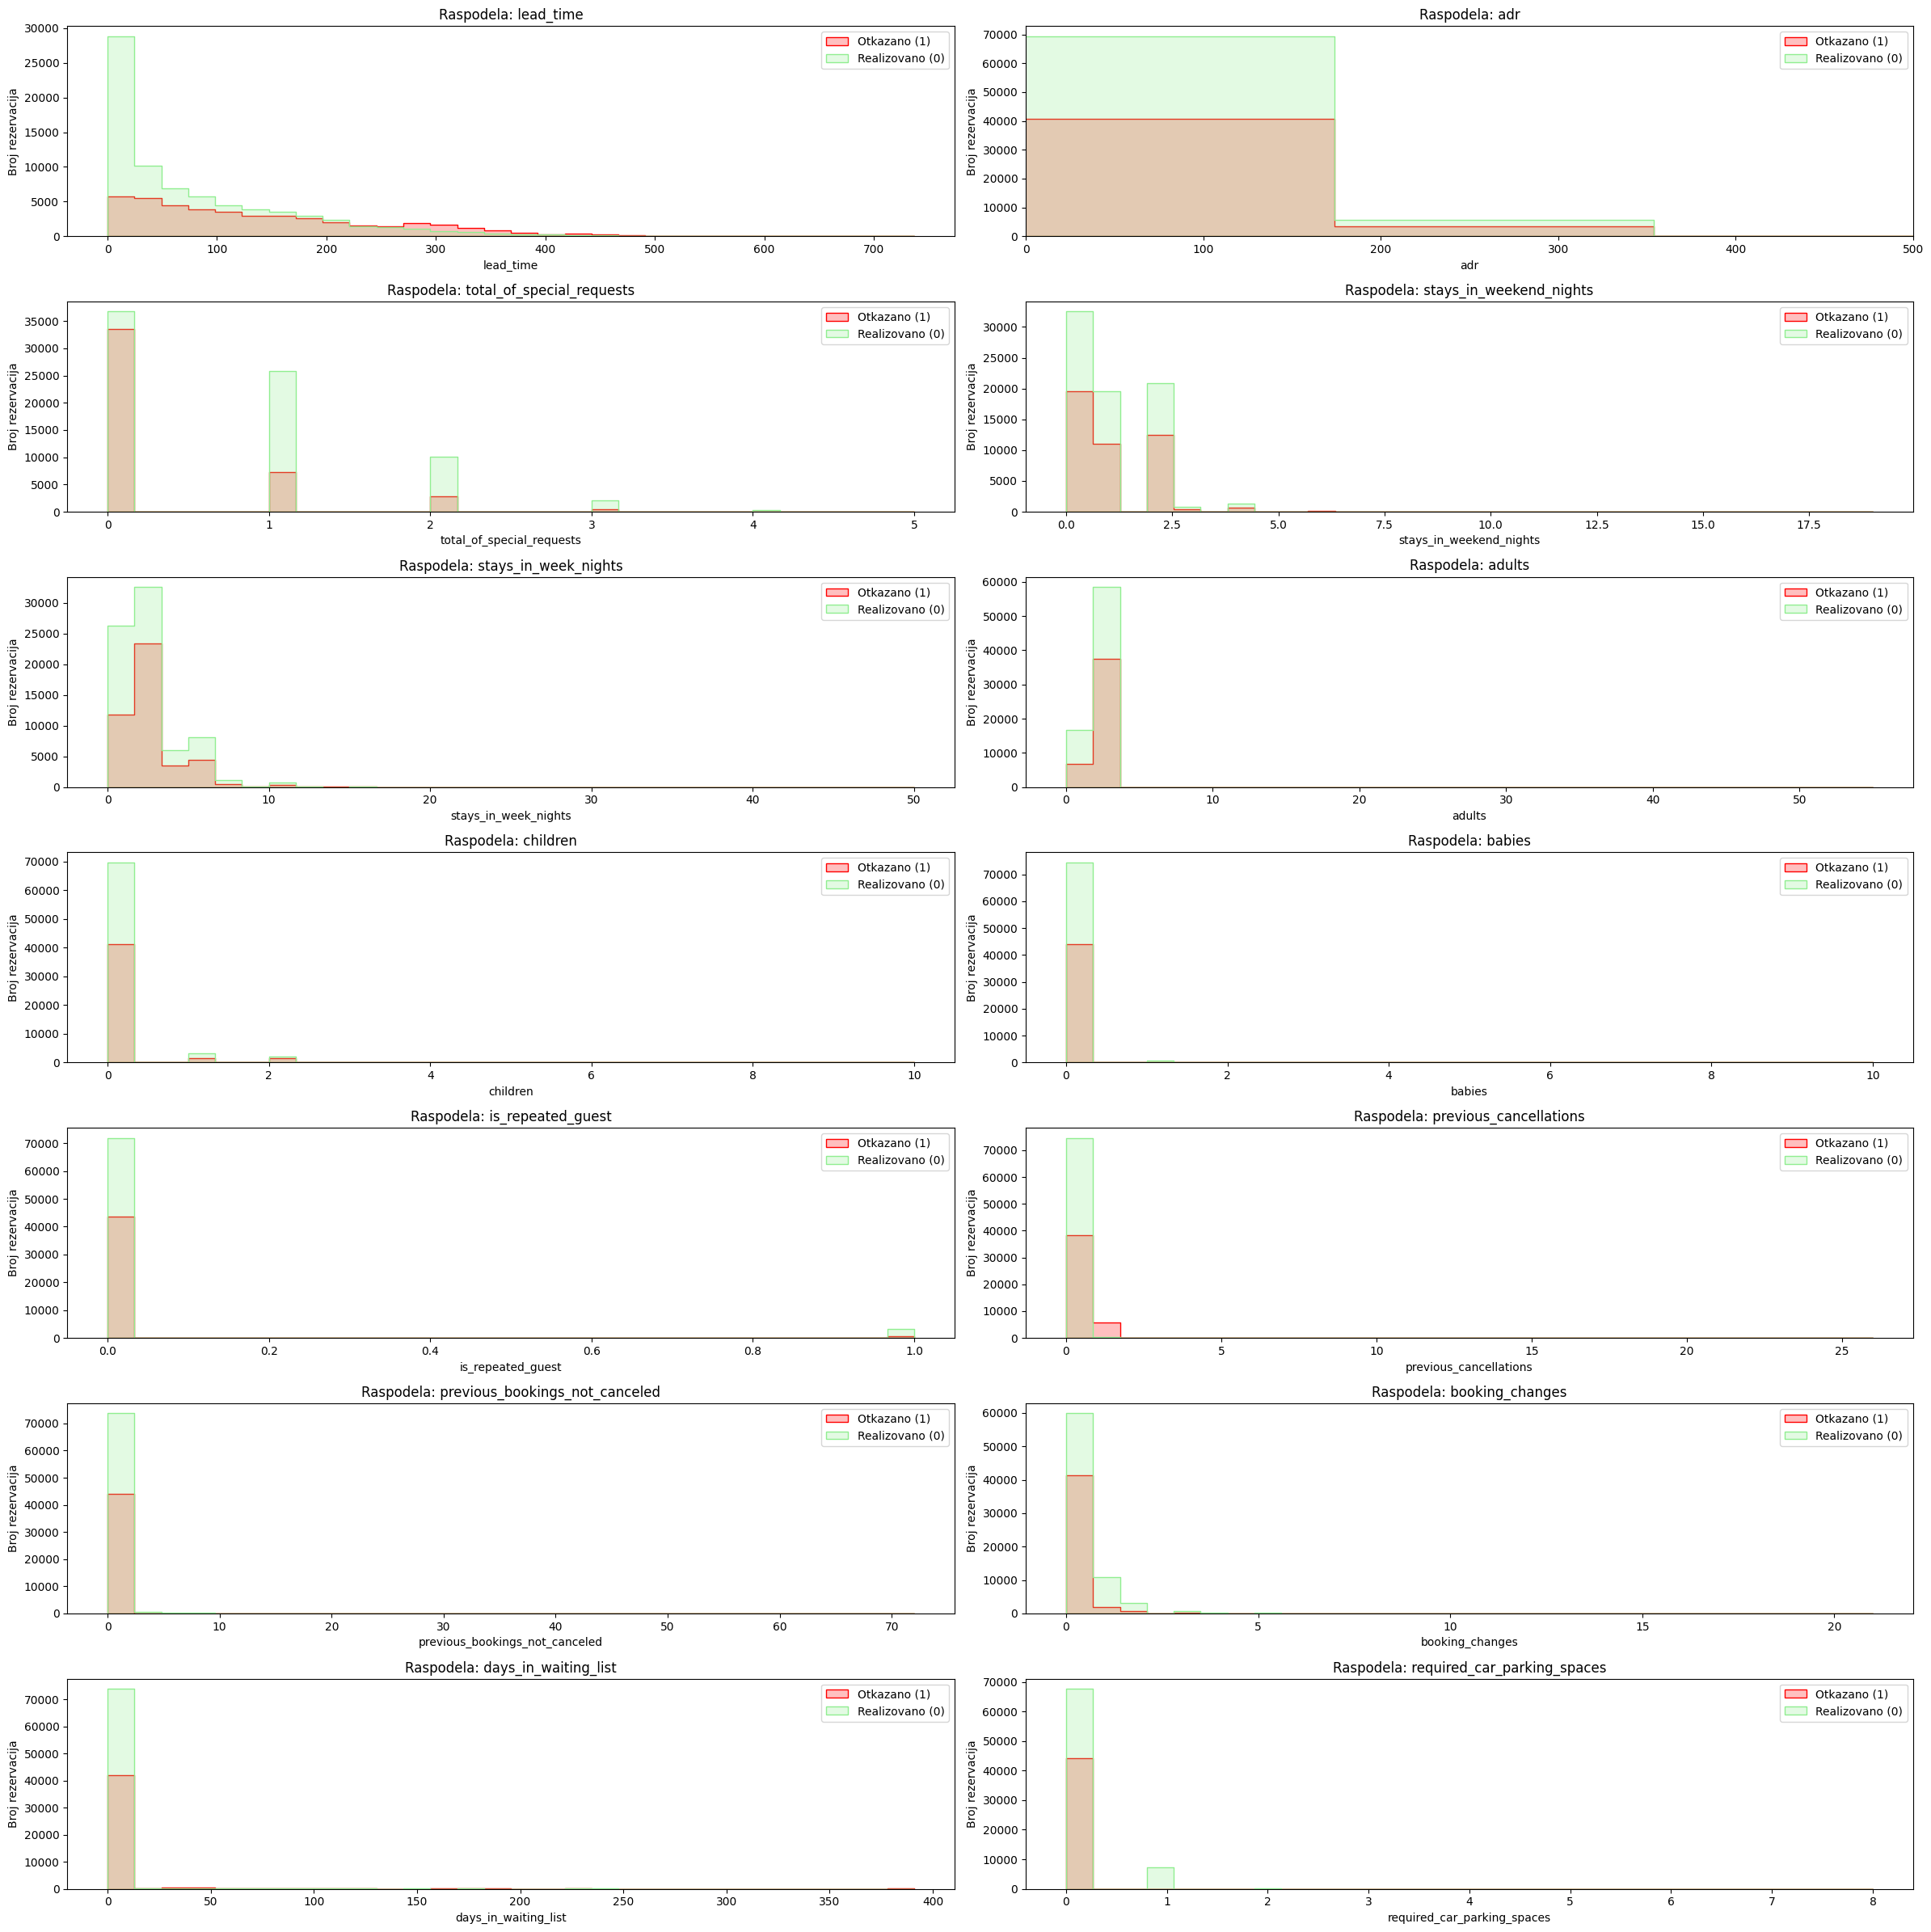

In [71]:
cols_to_plot = ['lead_time', 'adr', 'total_of_special_requests', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 
            'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes',
            'days_in_waiting_list', 'required_car_parking_spaces']

fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(24, 24))

axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    sb.histplot(data=df, x=col, hue='is_canceled', palette={0: 'lightgreen', 1: 'r'},element='step',bins=30,ax=axes[i])
    axes[i].set_title(f'Raspodela: {col}')
    axes[i].set_ylabel('Broj rezervacija')
    axes[i].legend(['Otkazano (1)', 'Realizovano (0)'])
    
    # Za adr autlajere, ograničavamo prikaz radi preglednosti
    if col == 'adr':
        axes[i].set_xlim(0, 500)
    

plt.tight_layout()
plt.show()

**Zapažanja**

Što je veći raspon između datuma rezervacije i dolaska, to je veća šansa otkazivanja.

Rezervacije bez posebnih zahteva imaju značajan broj otkazivanja. Slično i sa malim(ili nepostojećim) promenama rezervacije.

Ako je gost imao više od jednog prethodnog otkazivanja, sklon je ponovnom otkazivanju.

Gosti uglavnom ne dolaze više puta u isti hotel, već najviše rezervacija prave novi gosti.

Sa većim brojem rezervisanih radnih dana raste i šansa otkazivanja.

# Zaključak EDA

Ukloniti sve pomenute anomalije i autlajere

**Plan feature-a nakon analize**

Dodati:
1. room_mismatch binarni indikator dobijen poređenjem reserved_room_type i assigned_room_type, meri odstupanje od želja gosta.

Obrisati: 
1. name, email, phone-number, credit_card (nisu korisni za predikciju i vrednosti nisu prave)
2. company (94% nedostajućih vrednosti)
3. arrival_date_week_number (redundantno sa mesecom)
4. arrival_date_year (ako bi se model koristio u budućnosti, model obučen na godinama 2015, 2016, 2017 neće znati kako da tretira godinu 2026. Uklanjamo da model ne bi učio vremenski specifičan trend koji više ne važi)
5. arrival_date_day_of_month (sam po sebi nema jasno prediktivno značenje, sa 31 mogućom vrednošću, unosi dosta šuma)
6. reserved_room_type i assigned_room_type (kako ne bi dodali 20 novih indikatorskih kolona, najjači poslovni signal nije koje je tačno slovo sobe, već da li je gost dobio sobu koju je rezervisao.)

Transformacije:
1. country: Svodi se na TOP 10 najučestalijih zemalja, dok se ostale grupišu u kategoriju "Other"

# Priprema podataka

In [75]:
df_clean = df.copy()

cols_to_drop = ['name', 'email', 'phone-number', 'credit_card', 'reservation_status', 'reservation_status_date',
                'company', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month']
df_clean.drop(columns=cols_to_drop, inplace=True)

df_clean = df_clean[(df_clean['adr'] > 0) & (df_clean['adr'] < 520)]
df_clean = df_clean[(df_clean['adults'] >= 1)]
df_clean = df_clean[(df_clean['children'].fillna(0) <= 3) & (df_clean['babies'] <= 2)]

In [ ]:
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['agent'].fillna(0, inplace=True)

In [77]:
df_clean['room_mismatch'] = (df_clean['reserved_room_type'] != df_clean['assigned_room_type']).astype(int)
df_clean['has_agent'] = (df_clean['agent'] != 0).astype(int)
df_clean.drop(columns=['reserved_room_type', 'assigned_room_type', 'agent'], inplace=True)

In [84]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
month_num = df_clean['arrival_date_month'].map(month_map)

df_clean['month_sin'] = np.sin(2 * np.pi * month_num / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * month_num / 12)

df_clean.drop(columns=['arrival_date_month'], inplace=True)

In [85]:
top_countries = df_clean['country'].value_counts().nlargest(10).index
df_clean['country'] = df_clean['country'].apply(lambda x: x if x in top_countries else 'Other')

In [86]:
print(f"Broj redova nakon čišćenja: {df_clean.shape[0]}. Broj kolona: {df_clean.shape[1]}")

Broj redova nakon čišćenja: 117178. Broj kolona: 26


In [87]:
df_clean.columns.to_list()

['hotel',
 'is_canceled',
 'lead_time',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'deposit_type',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'room_mismatch',
 'has_agent',
 'month_sin',
 'month_cos']

In [88]:
X = df_clean.drop(columns=['is_canceled'])
y = df_clean['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"X_train oblik: {X_train.shape}")
print(f"X_test oblik: {X_test.shape}")

X_train oblik: (93742, 25)
X_test oblik: (23436, 25)
